In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import pandas as pd
import matplotlib
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

matplotlib.rcParams['figure.figsize'] = [13.0, 6.0]
plt.rcParams['figure.figsize'] = [13.0, 6.0]
np.random.seed(42)

In [3]:
def t_test(x1, x2, **kwargs):
    # underlying statsmodels test is correct but too laconic,
    # we need to show the intermediate steps.
    t, p, df = ttest_ind(x1, x2, **kwargs)
    
    s1 = np.std(x1)
    s2 = np.std(x2)
    
    n1 = len(x1)
    n2 = len(x2)
    
    # s-pooled
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) /
                 (n1 + n2 - 2))

    results = pd.DataFrame.from_records([{
        "n1": n1,
        "n2": n2,
        "x1_bar": np.mean(x1),
        "x2_bar": np.mean(x2),
        "s1": s1,
        "s2": s2,
        "s_pooled": s_pooled,
        "difference": np.mean(x2) - np.mean(x1),
        "t_statistic": t,
        "p_value": p,
        "degrees_of_freedom": df
    }])
    return results

In [4]:
def two_random_samples(n1=10, mu1=0.0, sigma1=1.0, n2=None, mu2=None, sigma2=None):
    if n2 is None: n2 = n1
    if mu2 is None: mu2 = mu1
    if sigma2 is None: sigma2 = sigma1
    
    x1=np.random.normal(mu1, sigma1, n1)
    x2=np.random.normal(mu2, sigma2, n2)
    return x1, x2

def repeat_t_test(repetitions=1000, *args, **kwargs):
    df = pd.concat( t_test(*two_random_samples(*args, **kwargs)) for _ in range(repetitions) )
    df = df.reset_index()
    df.head()
    return df
        

In [5]:
def plot_t_tests_for_n(n):
    t_tests = repeat_t_test(n1=n)
    plt.subplot(1,2,1)
    plt.scatter(t_tests['s_pooled'], t_tests['s1'], alpha=0.2)

    plt.subplot(1,2,2)
    sns.distplot(t_tests['t_statistic'], fit=stats.norm)

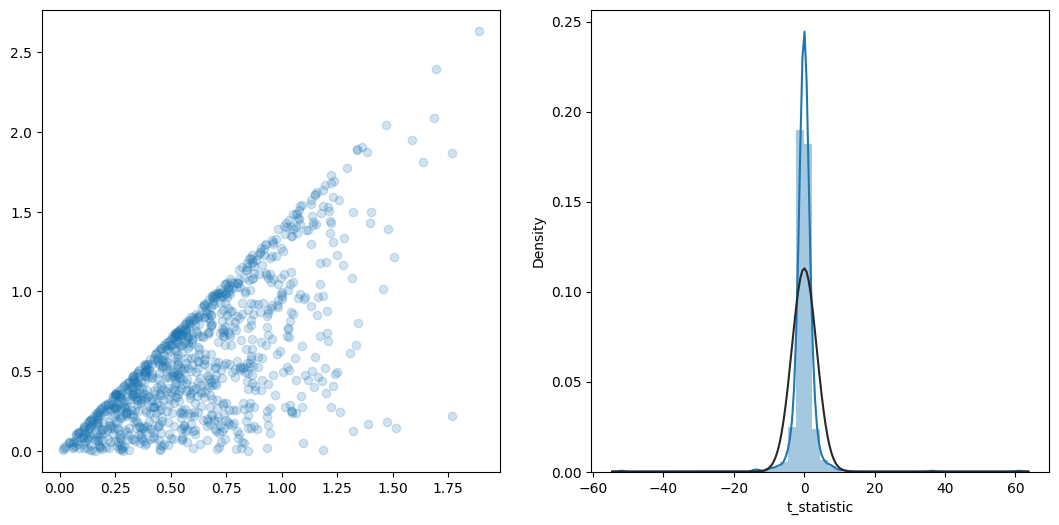

In [6]:
plot_t_tests_for_n(2)

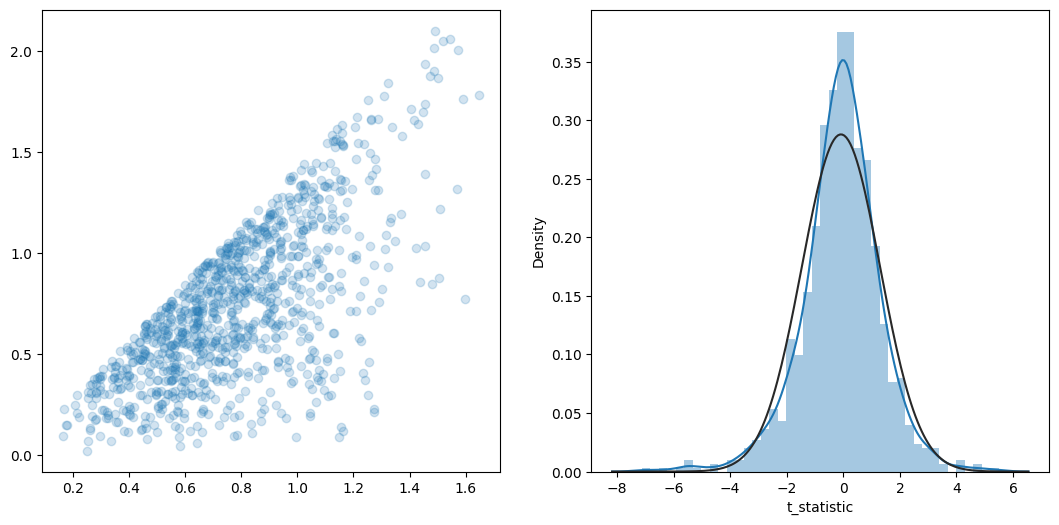

In [7]:
plot_t_tests_for_n(3)

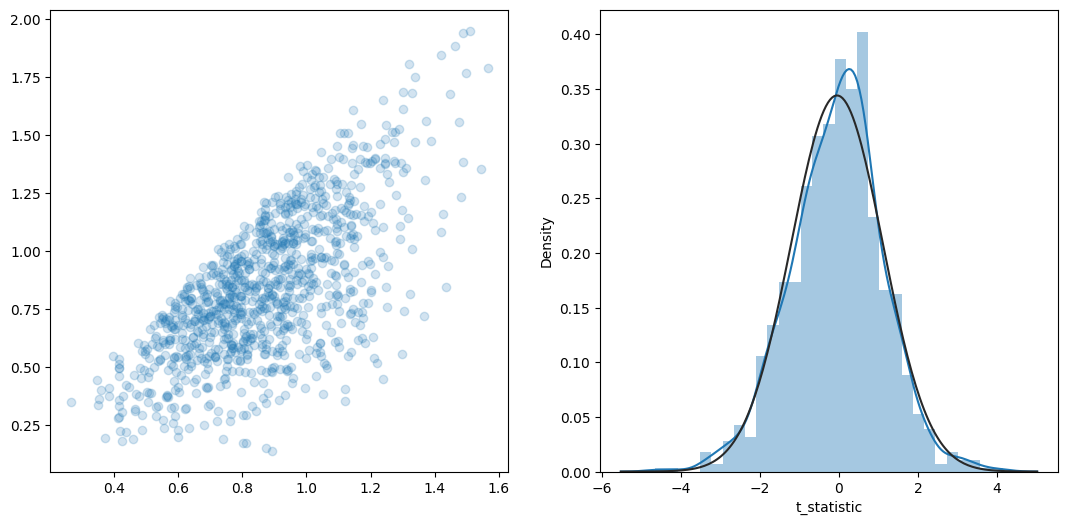

In [8]:
plot_t_tests_for_n(5)

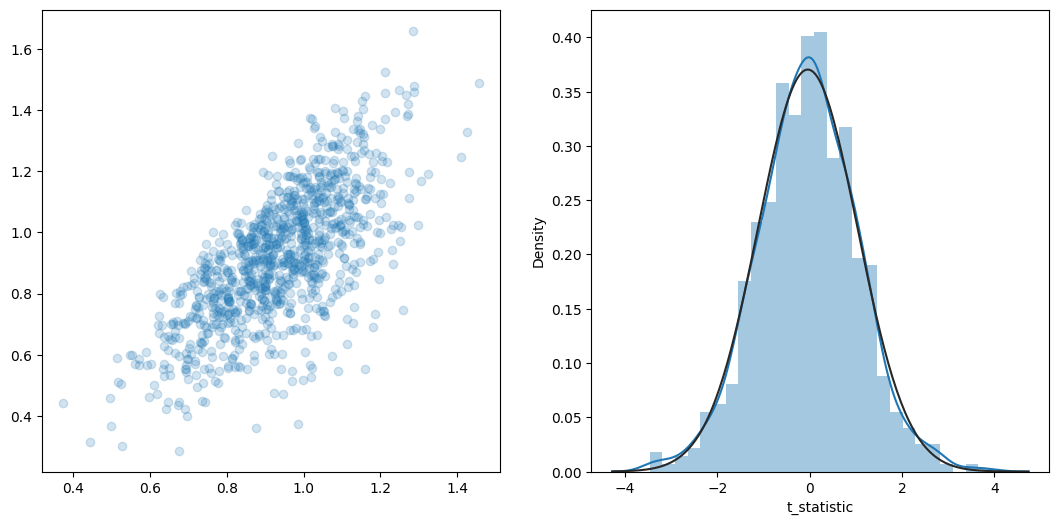

In [9]:
plot_t_tests_for_n(10)

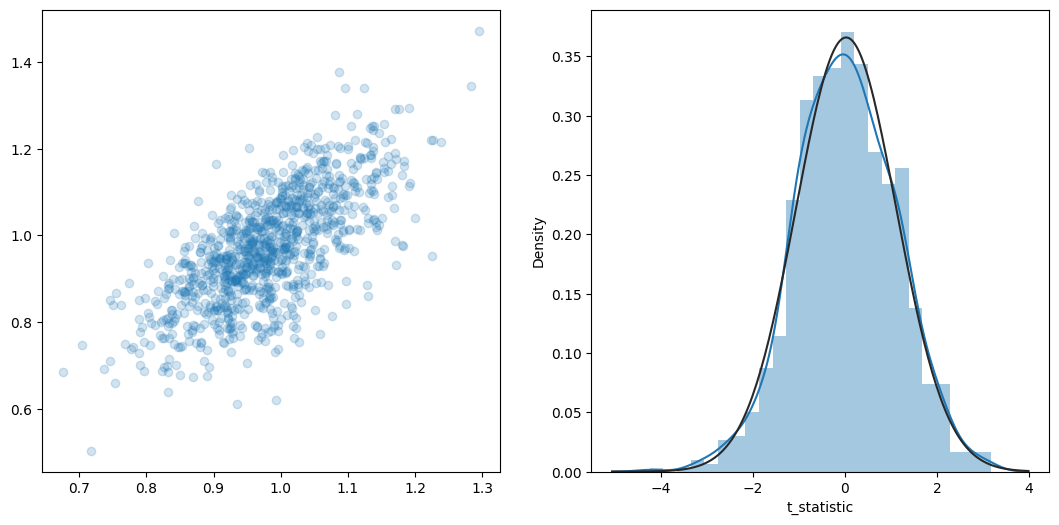

In [10]:
plot_t_tests_for_n(30)